# Lab 5 — Attention on a Road Network

**AI for Mobility · Module 7, Simulation, digital twins, and operations**

In Module 2 you met attention through language: to read the word *bank*, some
words in the sentence matter far more than others, and which ones matter depends
on what those words actually are — not on where they sit. A fixed weighting
cannot express that, so the weights are computed from the values themselves.

This lab asks whether the same argument holds on a road network, and then
**measures whether it pays**. It does not: not always. You will find one traffic
rule where attention buys you nothing over a one-line fixed aggregator, and
another where it wins — and the difference between them is the whole lesson.

**What you will build.** One message-passing layer with six interchangeable
aggregators, two ground-truth traffic rules taken from flow theory, and a
controlled comparison across them. Four of the aggregators are generic
(`mean`, `sum`, `max`, `attention`); **two of them encode what a traffic
engineer already knows** — that a queue backs up from downstream, or that
arriving flow comes from upstream. Those two are the interesting competitors.

**What it proves.** *Attention wins exactly where the weighting is the thing you
do not know — and even then, knowing which neighbours to listen to is worth more
than learning how much to weight them.*

**Check it against.** A persistence baseline (predict that nothing changes),
and — the comparison that actually bites — the fixed aggregator that encodes
your domain knowledge. Beating `mean` proves nothing. Beating a traffic
engineer's prior is the bar.

*Runtime ~4 minutes on a laptop CPU. No GPU, no downloads, no data files.
Everything on this page is generated here.*

Reads with {doc}`../module7/notes` §7.2.

## 0 · Setup

`numpy` for the traffic, `torch` for the network, `matplotlib` for the pictures.
Nothing is downloaded. If you are on Colab everything below is already installed.

In [1]:
# %pip install --quiet numpy torch matplotlib
import numpy as np, torch, torch.nn as nn, math
import matplotlib.pyplot as plt
from collections import deque

torch.set_num_threads(4)
GREEN, GOLD, RUST, BLUE = "#006747", "#B79F4D", "#B5581E", "#0E6E9E"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("numpy", np.__version__, "| torch", torch.__version__)

numpy 2.4.4 | torch 2.14.0+cpu


## 1 · A network to work on

Same generator as the Module 7 companion: a perturbed lattice with segments
removed and a few diagonals, so intersections end up with anywhere from 1 to 5
connections depending on the draw.
Traffic heads toward the CBD, which fixes which neighbours are **upstream**
(they feed you) and which are **downstream** (you feed them).

Look at the picture before reading any equation — everything later in the lab
happens on this graph.

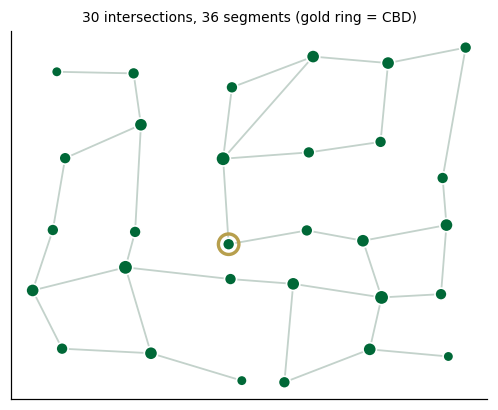

degree histogram (1..5): [ 3 15  9  3  0]
nodes with 2+ upstream feeders: 11 of 30


In [2]:
def make_network(rows, cols, seed=0, drop=0.28, diag=0.10, jitter=0.20):
    """Perturbed lattice; drop segments while keeping the graph connected."""
    rng = np.random.default_rng(seed)
    n = rows * cols
    ix = lambda r, c: r * cols + c
    pos = np.array([[c + rng.normal(0, jitter), r + rng.normal(0, jitter)]
                    for r in range(rows) for c in range(cols)])
    E = set()
    for r in range(rows):
        for c in range(cols):
            if c + 1 < cols: E.add((ix(r, c), ix(r, c + 1)))
            if r + 1 < rows: E.add((ix(r, c), ix(r + 1, c)))
    for r in range(rows - 1):
        for c in range(cols - 1):
            if rng.random() < diag: E.add((ix(r, c), ix(r + 1, c + 1)))
    E = [tuple(e) for e in E]; rng.shuffle(E)
    adj = {i: set() for i in range(n)}
    for a, b in E: adj[a].add(b); adj[b].add(a)

    def connected():
        seen, q = {0}, deque([0])
        while q:
            u = q.popleft()
            for v in adj[u]:
                if v not in seen: seen.add(v); q.append(v)
        return len(seen) == n

    keep, dropped, target = list(E), 0, int(len(E) * drop)
    for a, b in E:
        if dropped >= target: break
        adj[a].discard(b); adj[b].discard(a)
        if connected() and adj[a] and adj[b]: keep.remove((a, b)); dropped += 1
        else: adj[a].add(b); adj[b].add(a)

    # CBD = node nearest the centroid; BFS distance from it is the flow field
    cbd = int(np.argmin(((pos - pos.mean(0)) ** 2).sum(1)))
    dist = np.full(n, -1); dist[cbd] = 0; q = deque([cbd])
    while q:
        u = q.popleft()
        for v in adj[u]:
            if dist[v] < 0: dist[v] = dist[u] + 1; q.append(v)

    src, dst, ea = [], [], []
    up = {u: [] for u in range(n)}; dn = {u: [] for u in range(n)}
    for a, b in keep:
        for v, u in ((a, b), (b, a)):
            src.append(v); dst.append(u)
            ea.append(1.0 if dist[v] < dist[u] else (-1.0 if dist[v] > dist[u] else 0.0))
            (up if dist[v] > dist[u] else dn)[u].append(v)
    return dict(n=n, pos=pos, edges=keep, adj={k: sorted(v) for k, v in adj.items()},
                deg=np.array([len(adj[i]) for i in range(n)]), cbd=cbd, dist=dist,
                src=np.array(src), dst=np.array(dst),
                ea=np.array(ea, dtype=np.float32), up=up, dn=dn)


def draw(net, k=None, ax=None, title=""):
    ax = ax or plt.subplots(figsize=(4.4, 3.6))[1]
    P = net["pos"]
    for a, b in net["edges"]:
        ax.plot(*zip(P[a], P[b]), color="#c3d2cb", lw=1.2, zorder=1)
    c = k if k is not None else np.zeros(net["n"])
    s = ax.scatter(P[:, 0], P[:, 1], c=c, cmap="RdYlGn_r", vmin=0, vmax=1,
                   s=34 + 14 * net["deg"], edgecolors="w", lw=1.1, zorder=3)
    ax.scatter(*P[net["cbd"]], s=180, facecolors="none", edgecolors=GOLD, lw=2.2, zorder=4)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    return s

net = make_network(5, 6, seed=12)
fig, ax = plt.subplots(figsize=(4.6, 3.8))
draw(net, title=f"{net['n']} intersections, {len(net['edges'])} segments "
                f"(gold ring = CBD)", ax=ax)
plt.tight_layout(); plt.show()
print("degree histogram (1..5):", np.bincount(net["deg"], minlength=6)[1:6])
print("nodes with 2+ upstream feeders:",
      sum(1 for u in range(net["n"]) if len(net["up"][u]) >= 2), "of", net["n"])

## 2 · The fundamental diagram decides who matters

Here is the piece of traffic theory that makes this lab work, and it is worth
pausing on because it corrects an intuition most people have.

Ask: *of the links feeding into mine, which one influences my next-step density
most?* The tempting answer is "the most congested one." It is wrong. What a
feeder actually delivers is **flow**, not density, and flow follows the
fundamental diagram — here Greenshields, \(q(k) = k(1-k)\):

- a nearly **empty** feeder (k → 0) delivers almost nothing;
- a nearly **jammed** feeder (k → 1) also delivers almost nothing;
- the feeder near **capacity** (k ≈ 0.5) dominates.

Influence is *non-monotone* in the neighbour's own value. No fixed rule —
"average them", "take the biggest" — can express that. Hold that thought.

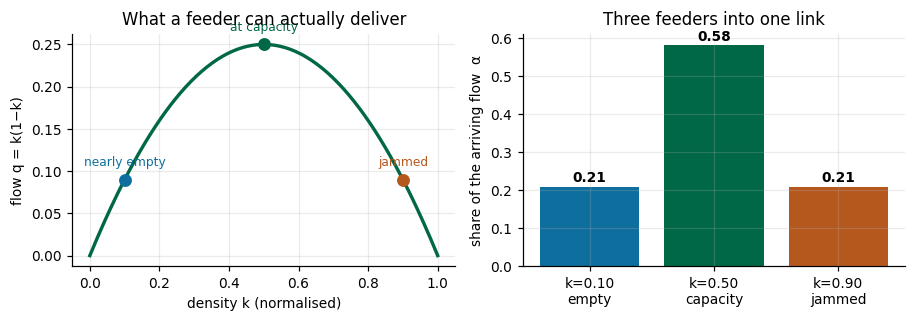

weights: [0.209 0.581 0.209]  they sum to 1.0
the densest feeder (k=0.90) carries only 21% of the arriving flow;
the one at capacity carries 58%.


In [3]:
q = lambda k: k * (1.0 - k)      # Greenshields flow, peak at k = 0.5

kk = np.linspace(0, 1, 200)
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.0))
ax[0].plot(kk, q(kk), color=GREEN, lw=2.2)
ax[0].set_xlabel("density k (normalised)"); ax[0].set_ylabel("flow q = k(1−k)")
ax[0].set_title("What a feeder can actually deliver")
for kv, lab, col in [(0.10, "nearly empty", BLUE), (0.50, "at capacity", GREEN),
                     (0.90, "jammed", RUST)]:
    ax[0].scatter([kv], [q(kv)], s=55, color=col, zorder=5)
    ax[0].annotate(lab, (kv, q(kv)), textcoords="offset points", xytext=(0, 9),
                   ha="center", fontsize=8, color=col)

ks = np.array([0.10, 0.50, 0.90])
w = q(ks) / q(ks).sum()
ax[1].bar(["k=0.10\nempty", "k=0.50\ncapacity", "k=0.90\njammed"], w,
          color=[BLUE, GREEN, RUST])
ax[1].set_ylabel("share of the arriving flow  α")
ax[1].set_title("Three feeders into one link")
for i, v in enumerate(w):
    ax[1].text(i, v + .012, f"{v:.2f}", ha="center", fontsize=9, weight="bold")
plt.tight_layout(); plt.show()

print("weights:", np.round(w, 3), " they sum to", round(w.sum(), 6))
print("the densest feeder (k=0.90) carries only %.0f%% of the arriving flow;" % (100*w[2]))
print("the one at capacity carries %.0f%%." % (100*w[1]))

> **Your turn — exercise 1.** Suppose the three feeders are at k = 0.35, 0.45 and
> 0.95. Before running anything, say which one you expect to dominate and roughly
> by how much. Then change `ks` above and check. Were you close? The pair at 0.35
> and 0.45 is the interesting comparison — how much does a 0.10 difference in
> density buy in influence, and why so little?

## 3 · Two traffic rules

Both are one-hop rules: each link updates from its immediate neighbours only.
They differ in **which neighbour matters, and how much**.

**Rule A — spillback.** A bottleneck link is pinned at jam. Every other link is
pulled toward the *worst* of its downstream neighbours and otherwise recovers.
The selector is a hard **max**: one neighbour governs and the rest are ignored.

$$k_u(t{+}1) = \mathrm{clip}\big(k_u + \beta\,(\max_{v \in \mathrm{down}(u)} k_v - k_u) - \gamma\big)$$

**Rule B — merge composition.** A link relaxes toward the **flow-weighted**
average density of what is arriving, with the weights from section 2.

$$\bar{k}_u = \sum_{v \in \mathrm{up}(u)} \alpha_v\, k_v, \qquad
\alpha_v = \frac{q(k_v)}{\sum_{v'} q(k_{v'})}, \qquad
k_u(t{+}1) = \mathrm{clip}\big((1-\theta)k_u + \theta \bar{k}_u - \gamma\big)$$

| Symbol | Meaning |
| --- | --- |
| $k_u$ | normalised density of link $u$ (0 = empty, 1 = jam) |
| $\alpha_v$ | the share of arriving flow contributed by feeder $v$ — a weight that sums to 1 over the feeders |
| $q(k)$ | the fundamental diagram: what a link at density $k$ can deliver |
| $\beta, \theta$ | how fast a link responds to its neighbours |
| $\gamma$ | recovery per step |

**In words:** rule A says *one* neighbour governs you; rule B says *all of them
do, in proportion to what they are actually delivering.*

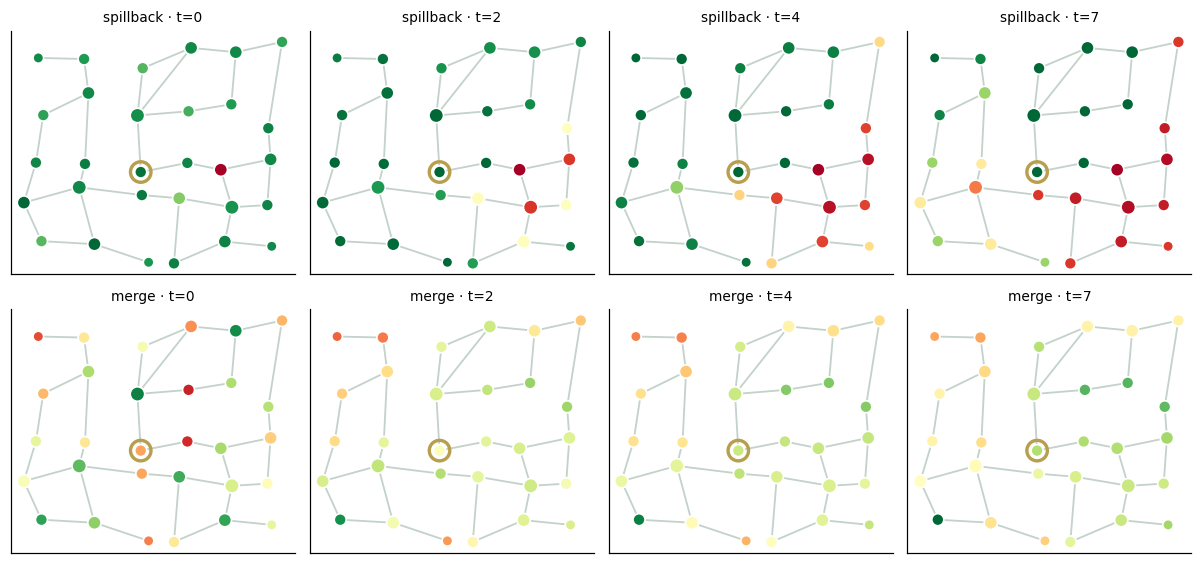

weight spread at multi-feeder links: mean 0.187, 90th pct 0.656
the most INFLUENTIAL feeder is not the DENSEST one in 22/110 = 20% of cases


In [4]:
BETA, GAMMA, THETA = 0.70, 0.02, 0.65

def rollout(net, steps, rng, rule):
    n = net["n"]
    if rule == "spillback":
        k = np.clip(rng.normal(0.08, 0.05, n), 0, 1)
        cand = np.where(net["dist"] <= max(1, net["dist"].max() // 2))[0]
        bn = rng.choice(cand)
        traj = []
        for _ in range(steps):
            k = k.copy(); k[bn] = 1.0
            traj.append(k.copy())
            md_ = np.array([max([k[v] for v in net["dn"][u]], default=0.0)
                            for u in range(n)])
            k = np.clip(k + BETA * (md_ - k) - GAMMA, 0, 1)
        return np.array(traj)

    k = np.clip(rng.uniform(0.05, 0.95, n), 0.02, 0.98); traj = []
    for _ in range(steps):
        traj.append(k.copy())
        S = q(k); tgt = np.zeros(n)
        for u in range(n):
            fed = net["up"][u]
            if not fed: tgt[u] = k[u]; continue
            d = sum(S[v] for v in fed)
            tgt[u] = (sum((S[v] / d) * k[v] for v in fed) if d > 1e-9
                      else float(np.mean([k[v] for v in fed])))
        k = np.clip((1 - THETA) * k + THETA * tgt - GAMMA, 0, 1)
    return np.array(traj)

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(11, 5.2))
for row, rule in enumerate(("spillback", "merge")):
    tr = rollout(net, 8, np.random.default_rng(3), rule)
    for j, t in enumerate((0, 2, 4, 7)):
        draw(net, tr[t], ax=axes[row][j], title=f"{rule} · t={t}")
plt.tight_layout(); plt.show()

# how uneven are the merge weights in practice? (0 would mean "mean would do")
tr = rollout(net, 10, np.random.default_rng(3), "merge")
spread, flips, tot = [], 0, 0
for t in range(10):
    S = q(tr[t])
    for u in range(net["n"]):
        fed = net["up"][u]
        if len(fed) < 2: continue
        a = np.array([S[v] for v in fed]); a = a / a.sum()
        spread.append(a.max() - a.min()); tot += 1
        if fed[int(np.argmax([S[v] for v in fed]))] != fed[int(np.argmax([tr[t][v] for v in fed]))]:
            flips += 1
print(f"weight spread at multi-feeder links: mean {np.mean(spread):.3f}, "
      f"90th pct {np.percentile(spread,90):.3f}")
print(f"the most INFLUENTIAL feeder is not the DENSEST one in "
      f"{flips}/{tot} = {flips/tot:.0%} of cases")

## 4 · One layer, six aggregators

Every aggregator below uses the **same message function**

$$m_{v \to u} = \tanh\big(W_m\,[\,h_v \,\|\, h_u \,\|\, e_{v \to u}\,] + b_m\big)$$

and the same update. Only the way the messages are combined changes. That is
what makes this a controlled experiment: any difference you measure is
attributable to ⊕ and to nothing else.

> **This matters more than it looks.** The first version of this lab gave the
> attention branch a weaker message function than the others — attention "lost",
> and the conclusion would have been backwards. If you ever compare
> architectures, check that the thing you changed is the *only* thing you
> changed.

For attention we follow the transformer vocabulary from Module 2: a **query**
from the receiving link, a **key** from the sending link, and a score turned
into weights by a softmax over that link's own neighbourhood.

Six aggregators, in two groups:

| ⊕ | What it assumes | Knows any traffic? |
| --- | --- | --- |
| `mean` | every neighbour counts equally | no |
| `sum` | every neighbour counts equally, and how many there are matters | no |
| `max` | exactly one neighbour governs | no |
| `dmax` | one neighbour governs, and it is **downstream** | yes — queues back up |
| `umean` | all **upstream** neighbours count, equally | yes — flow arrives from upstream |
| `attn` | the weights are learned from the values | no, but it can discover them |

`dmax` and `umean` are one extra line of code each — they simply mask the
message by the edge feature before reducing. They cost **zero** extra
parameters. Keep an eye on them.

### Your turn — exercise 2

Fill in the attention coefficient. You are given a score `s` for every directed
edge and the destination index `dst`. Produce `alpha` such that, **for each
receiving node separately**, the weights over its incoming edges sum to 1.

```python
def attention_weights(s, dst, n):
    # s   : [B, E]  one score per directed edge
    # dst : [E]     which node each edge points at
    # n   : number of nodes
    # YOUR CODE HERE — return alpha, shape [B, E]
    ...
```

Two traps worth thinking about before you write it:

1. There is no fixed number of edges per node, so you cannot reshape into a
   rectangle and call `softmax(dim=-1)`. The sum has to be a *scatter*.
2. Subtract a max before exponentiating, or long scores overflow.

### Worked solution

In [5]:
def attention_weights(s, dst, n):
    """Softmax over each node's own incoming edges. s: [B,E] -> alpha: [B,E]"""
    B = s.shape[0]
    di = dst[None, :].expand(B, -1)
    s = s - s.max()                                    # overflow guard
    ex = s.exp()
    den = torch.zeros(B, n).scatter_add(1, di, ex)     # per-node normaliser
    return ex / den.gather(1, di).clamp(min=1e-9)

# check: do the weights sum to 1 on every node that has any incoming edge?
_src = torch.as_tensor(net["src"]); _dst = torch.as_tensor(net["dst"])
_s = torch.randn(2, len(_src))
_al = attention_weights(_s, _dst, net["n"])
_tot = torch.zeros(2, net["n"]).scatter_add(1, _dst[None].expand(2, -1), _al)
_has = torch.zeros(net["n"]).index_add(0, _dst, torch.ones(len(_dst))) > 0
print("max deviation from 1.0 across all nodes and batch:",
      float((_tot[:, _has] - 1).abs().max()))
assert float((_tot[:, _has] - 1).abs().max()) < 1e-5, "weights must sum to 1 per node"
print("passed — the weights are a proper distribution over each neighbourhood")

max deviation from 1.0 across all nodes and batch: 1.1920928955078125e-07
passed — the weights are a proper distribution over each neighbourhood


In [6]:
class Layer(nn.Module):
    """Identical message function for every aggregator; only the combination differs."""
    def __init__(self, d, agg, dynamic=True):
        super().__init__()
        self.agg, self.dynamic = agg, dynamic
        self.msg = nn.Linear(2 * d + 1, d)
        self.upd = nn.Linear(2 * d, d)
        if agg == "attn":
            self.Wq, self.Wk = nn.Linear(d, d), nn.Linear(d, d)
            if dynamic:                       # GATv2: nonlinearity BEFORE the score vector
                self.sc1, self.sc2 = nn.Linear(2 * d + 1, d), nn.Linear(d, 1, bias=False)
            else:                             # original GAT: score vector, THEN nonlinearity
                self.sc = nn.Linear(2 * d + 1, 1)

    def scores(self, h, src, dst, ea):
        Bn = h.shape[0]
        z = torch.cat([self.Wq(h)[:, dst], self.Wk(h)[:, src],
                       ea[None, :, None].expand(Bn, -1, 1)], -1)
        if self.dynamic:
            return self.sc2(torch.nn.functional.leaky_relu(self.sc1(z), 0.2)).squeeze(-1)
        return torch.nn.functional.leaky_relu(self.sc(z), 0.2).squeeze(-1)

    def forward(self, h, src, dst, ea, n):
        B, _, d = h.shape
        ix = dst[None, :, None].expand(B, -1, d)
        m = torch.tanh(self.msg(torch.cat(
            [h[:, src], h[:, dst], ea[None, :, None].expand(B, -1, 1)], -1)))
        if self.agg == "attn":
            alpha = attention_weights(self.scores(h, src, dst, ea), dst, n)
            a = torch.zeros(B, n, d).scatter_add(1, ix, alpha[..., None] * m)
        elif self.agg in ("max", "dmax"):
            mm = m
            if self.agg == "dmax":        # KNOWLEDGE: a queue backs up from DOWNSTREAM
                keep = (ea > 0).float()[None, :, None]
                mm = m * keep + (-1e9) * (1 - keep)
            a = torch.full((B, n, d), -1e9).scatter_reduce(1, ix, mm, reduce="amax",
                                                           include_self=True)
            a = torch.where(a < -1e8, torch.zeros_like(a), a)
        elif self.agg == "umean":         # KNOWLEDGE: arriving flow comes from UPSTREAM
            keep = (ea < 0).float()[None, :, None]
            a = torch.zeros(B, n, d).scatter_add(1, ix, m * keep)
            cnt = torch.zeros(n).index_add(0, dst, (ea < 0).float())
            a = a / cnt.clamp(min=1)[None, :, None]
        else:
            a = torch.zeros(B, n, d).scatter_add(1, ix, m)
            if self.agg == "mean":
                cnt = torch.zeros(n).index_add(0, dst, torch.ones_like(dst, dtype=torch.float))
                a = a / cnt.clamp(min=1)[None, :, None]
        return torch.tanh(self.upd(torch.cat([h, a], -1)))


class Net(nn.Module):
    def __init__(self, d=16, L=2, agg="mean", dynamic=True):
        super().__init__()
        self.enc = nn.Linear(1, d)
        self.layers = nn.ModuleList([Layer(d, agg, dynamic) for _ in range(L)])
        self.head = nn.Linear(d, 1)

    def forward(self, k, src, dst, ea):
        h = torch.tanh(self.enc(k[..., None]))
        for L in self.layers:
            h = L(h, src, dst, ea, k.shape[1])
        return self.head(h).squeeze(-1)


for a in ("mean", "attn"):
    print(f"{a:>5s}: {sum(p.numel() for p in Net(16,2,a).parameters()):,} parameters")
print("\nNote: no parameter count depends on the number of intersections.")

 mean: 2,193 parameters
 attn: 4,401 parameters

Note: no parameter count depends on the number of intersections.


## 5 · The training harness

Train on two networks, test on a **third, larger one the model has never seen** —
a split across networks, not across time. A split across time would let a model
memorise locations and still look good, which is the failure this comparison is
meant to expose.

In [7]:
def pack(nets, rule, n_roll=8, steps=10, seed=0):
    rng = np.random.default_rng(seed); out = []
    for nt in nets:
        X, Y = [], []
        for _ in range(n_roll):
            t = rollout(nt, steps, rng, rule)
            for i in range(steps - 1): X.append(t[i]); Y.append(t[i + 1])
        out.append(((torch.as_tensor(nt["src"]), torch.as_tensor(nt["dst"]),
                     torch.as_tensor(nt["ea"])),
                    torch.tensor(np.array(X), dtype=torch.float32),
                    torch.tensor(np.array(Y), dtype=torch.float32)))
    return out

def train(model, packs, epochs=300, lr=8e-3, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        for (s, d, e), X, Y in packs:
            loss = ((model(X, s, d, e) - Y) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
    return model

@torch.no_grad()
def rmse(model, packs):
    se = n = 0
    for (s, d, e), X, Y in packs:
        se += ((model(X, s, d, e) - Y) ** 2).sum().item(); n += Y.numel()
    return math.sqrt(se / n)

def persistence(packs):
    se = n = 0
    for _, X, Y in packs:
        se += ((X - Y) ** 2).sum().item(); n += Y.numel()
    return math.sqrt(se / n)

TRAIN = [make_network(4, 5, seed=11), make_network(4, 6, seed=12)]
TEST  = [make_network(5, 6, seed=91)]
print("train N =", [t["n"] for t in TRAIN], " test N =", [t["n"] for t in TEST])

def compare(rule, epochs=300, seed=0):
    tr, te = pack(TRAIN, rule, seed=1), pack(TEST, rule, seed=99)
    print(f"{rule}:  persistence RMSE {persistence(te):.4f}   (the floor to clear)")
    res = {}
    for agg in ("mean", "sum", "max", "dmax", "umean", "attn"):
        res[agg] = rmse(train(Net(16, 2, agg), tr, epochs=epochs, seed=seed), te)
        print(f"   {agg:<5s} {res[agg]:.4f}")
    best = min(res, key=res.get)
    print(f"   -> best: {best}")
    return res

train N = [20, 24]  test N = [30]


## 6 · Experiment 1 — the spillback rule

> **Your turn — exercise 3.** Before you run the next cell, write down which
> aggregator you expect to win, and why. Re-read rule A in section 3 first; the
> answer is visible in the equation.

In [8]:
res_A = compare("spillback")

spillback:  persistence RMSE 0.0987   (the floor to clear)


   mean  0.0975


   sum   0.0257


   max   0.0193


   dmax  0.0153


   umean 0.0815


   attn  0.0235
   -> best: dmax


Two things to notice, and the second is the one worth carrying.

**`dmax` should be at or near the top.** Rule A *is* a max over downstream
neighbours, so `dmax` has exactly the right shape built in and has nothing to
learn about the weighting. On the full sweep (six seeds, larger networks —
section 8) it lands at **0.0081** against
attention's **0.0080**. That is a tie — and
`dmax` gets it with **half the parameters**
(2,193 vs 4,401) and a far tighter seed spread
(0.0069–0.0112 against
0.0054–0.0148).
**When you already know the selector, writing it down beats learning it.**

**`umean` should be near the bottom** — worse than plain `mean`, in fact, at
**0.0560**, barely better than persistence
(0.0655). It confidently looks at the wrong half of the
neighbourhood. Domain knowledge is powerful in exactly the way it is dangerous:
encoded correctly it beats everything here, encoded backwards it is worse than
assuming nothing.

## 7 · Experiment 2 — the merge rule

Now the weighting is a non-monotone function of the neighbour's own density, and
no fixed aggregator has that shape. `mean` assumes all feeders are equal; `sum`
never normalises; `max` picks one and throws away the blend.

In [9]:
res_B = compare("merge")

merge:  persistence RMSE 0.0700   (the floor to clear)


   mean  0.0284


   sum   0.0346


   max   0.0195


   dmax  0.0647


   umean 0.0156


   attn  0.0152
   -> best: attn


Now attention should be first — at **0.0110** on the
full sweep, against `max` 0.0164 and `mean`
0.0214. The weighting here is non-monotone in the
neighbour's own density and no fixed rule has that shape, so the learned one wins.

But look at **`umean`: 0.0122**. It has no idea how to
weight anything — it is a flat average — and it still comes within
10%
of attention, for zero extra parameters. All it knows is *which* neighbours to
listen to.

Put those side by side and the real finding appears:

- knowing the **support** (upstream only) took error from
  0.0214 to 0.0122 —
  a 43% cut, free;
- learning the **weights** on top of that took it to
  0.0110 — a further
  10%, for
  double the parameters and, as section 8 shows, several times the variance.

**Structure first, weighting second.** That ordering is the practical lesson of
this lab, and it is the opposite of how most people reach for architectures.

## 8 · The full sweep

Your run above used two small training networks, one test network, one seed and
300 epochs, so that it finishes while you watch. The table below is the same
experiment run properly: three training networks (N = 25, 30, 30), three unseen
test networks (N = 42, 49, 36), 400 epochs, **six seeds per cell**. The spread is
shown because with six seeds it has to be.

**Test RMSE, mean over six seeds (best–worst in small type). Lower is better.**

| ⊕ | Rule A — spillback | Rule B — merge |
| --- | --- | --- |
| `mean` | 0.0168 <sub>0.0134–0.0193</sub> | 0.0214 <sub>0.0194–0.0259</sub> |
| `sum` | 0.0139 <sub>0.0118–0.0157</sub> | 0.0340 <sub>0.0196–0.0454</sub> |
| `max` | 0.0101 <sub>0.0081–0.0127</sub> | 0.0164 <sub>0.0145–0.0182</sub> |
| **`dmax`** · knows queues back up | 0.0081 <sub>0.0069–0.0112</sub> | 0.0619 <sub>0.0614–0.0631</sub> |
| **`umean`** · knows flow arrives from upstream | 0.0560 <sub>0.0559–0.0563</sub> | 0.0122 <sub>0.0095–0.0151</sub> |
| **attention** | 0.0080 <sub>0.0054–0.0148</sub> | 0.0110 <sub>0.0061–0.0255</sub> |
| *persistence* | *0.0655* | *0.0716* |

Parameters: 2,193 for every fixed aggregator including `dmax` and
`umean`; 4,401 for attention.

Read it column by column. On **rule A** the best method is a one-line fixed
aggregator that encodes what you knew, and attention merely matches it. On
**rule B** attention is genuinely first — but the fixed aggregator that knows
only the *support* is close behind, and the two generic aggregators that know
nothing are far back. The ordering of value is: **right support ≫ learned
weighting > generic reduction.**

### Before you trust this result

**What is the baseline?** Persistence sets the floor, but the comparison that
matters is against the knowledge-encoding aggregator, not against `mean`. A
paper that reports attention beating `mean` has not shown you the number you
need.

**How was the data split, and why is that honest?** Across networks, not across
time: train and test graphs are different sizes and shapes. A time split within
one network would reward memorising locations, which is the failure this
comparison exists to expose.

**What does it do on the ugly cases?** Look at the spreads. Attention is the
least stable method in the table on both rules — a
4.2× range across seeds on
rule B, where its worst seed (0.0255) is worse than
`umean`'s worst (0.0151). A single attention run reported
without a spread is a report of a seed. And `umean` on rule A
(0.0560) is the cautionary case: domain
knowledge encoded backwards is worse than encoding none at all.

One honest caveat about the whole lab: both ground truths are rules we wrote
down. Real traffic is not generated by a tidy one-hop rule, and published
cross-city gains are far smaller than anything here. Take the *shape* of the
result, not the magnitude.

## 9 · Optional — does your attention actually depend on who is asking?

*Skip this section if you are short on time; nothing later depends on it.*

There is a subtlety in the original Graph Attention Network (Veličković et al.,
ICLR 2018) worth knowing before you cite it. Its score is

$$e_{vu} = \mathrm{LeakyReLU}\big(a^{\top}[\,W h_u \,\|\, W h_v\,]\big)
= \mathrm{LeakyReLU}(c_u + s_v)$$

where $c_u$ depends only on the receiving node and $s_v$ only on the sender.
LeakyReLU is monotone, so $\arg\max_v e_{vu}$ is **the same for every $u$**:
the ranking of neighbours is global. Brody et al. (ICLR 2022) call this *static
attention* and fix it by putting the nonlinearity first,
$e_{vu} = a^{\top}\mathrm{LeakyReLU}(W[h_u \| h_v])$ — that is GATv2, and it
is the `dynamic=True` branch you have been using.

Does it matter in traffic? Rules A and B both have weights that depend only on
the *feeders*, so a global ranking is fine and static attention should cope. So
here is a third rule where it is not fine:

**Rule C — who governs me depends on my own state.** A link with room is governed
by what arrives from upstream; a link that is full is governed by what its
downstream neighbour will accept. The *identity* of the neighbour that matters
flips with the receiving link's own density.

$$k_u(t{+}1) = (1-\theta)k_u + \theta\big[(1-k_u)\,\bar{k}^{\,\mathrm{up}}_u + k_u\,\bar{k}^{\,\mathrm{down}}_u\big] - \gamma$$

We measure the mechanism directly with a **ranking-flip rate**: take two links
that share two neighbours and ask how often they disagree about which of the two
is more important. Static attention should be near zero by construction.

In [10]:
def rollout_C(nt, steps, rng):
    n = nt["n"]; k = np.clip(rng.uniform(0.05, 0.95, n), 0.02, 0.98); traj = []
    def wmix(k, S, nbrs, fb):
        d = sum(S[v] for v in nbrs)
        return (float(sum((S[v]/d) * k[v] for v in nbrs)) if d > 1e-9
                else float(np.mean([k[v] for v in nbrs])))
    for _ in range(steps):
        traj.append(k.copy()); S = q(k); tgt = np.zeros(n)
        for u in range(n):
            ku = k[u]
            umix = wmix(k, S, nt["up"][u], ku) if nt["up"][u] else ku
            dmix = wmix(k, S, nt["dn"][u], ku) if nt["dn"][u] else ku
            tgt[u] = (1 - ku) * umix + ku * dmix      # room -> upstream; full -> downstream
        k = np.clip((1 - THETA) * k + THETA * tgt - GAMMA, 0, 1)
    return np.array(traj)

def packC(nets, n_roll=8, steps=10, seed=0):
    rng = np.random.default_rng(seed); out = []
    for nt in nets:
        X, Y = [], []
        for _ in range(n_roll):
            t = rollout_C(nt, steps, rng)
            for i in range(steps - 1): X.append(t[i]); Y.append(t[i + 1])
        out.append(((torch.as_tensor(nt["src"]), torch.as_tensor(nt["dst"]),
                     torch.as_tensor(nt["ea"])),
                    torch.tensor(np.array(X), dtype=torch.float32),
                    torch.tensor(np.array(Y), dtype=torch.float32)))
    return out

@torch.no_grad()
def ranking_flip_rate(model, pk):
    """Two links sharing two neighbours: how often do they disagree on the order?"""
    (s, d, e), X, _ = pk
    h = torch.tanh(model.enc(X[..., None]))
    sc = model.layers[0].scores(h, s, d, e).mean(0).numpy()
    by = {}
    for i, (v, u) in enumerate(zip(s.numpy(), d.numpy())): by.setdefault(u, {})[v] = sc[i]
    us = list(by); flips = tot = 0
    for i in range(len(us)):
        for j in range(i + 1, len(us)):
            a, b = by[us[i]], by[us[j]]
            sh = sorted(set(a) & set(b))
            for x in range(len(sh)):
                for y in range(x + 1, len(sh)):
                    v1, v2 = sh[x], sh[y]; tot += 1
                    if (a[v1] - a[v2]) * (b[v1] - b[v2]) < 0: flips += 1
    return flips / tot if tot else float("nan")

trC, teC = packC(TRAIN, seed=1), packC(TEST, seed=99)
print(f"rule C: persistence RMSE {persistence(teC):.4f}\n")
for dyn, label in ((False, "static  (GAT 2018)"), (True, "dynamic (GATv2 2022)")):
    m = train(Net(16, 2, "attn", dynamic=dyn), trC, epochs=300, seed=0)
    print(f"  {label}:  RMSE {rmse(m, teC):.4f}   ranking-flip rate {ranking_flip_rate(m, teC[0]):.3f}")

rule C: persistence RMSE 0.0688



  static  (GAT 2018):  RMSE 0.0223   ranking-flip rate 0.000


  dynamic (GATv2 2022):  RMSE 0.0193   ranking-flip rate 0.083


On the full sweep (six seeds) the flip rate is **0.017** for static
attention against **0.142** for dynamic — roughly
8× more. Static attention's neighbour
ranking is essentially fixed no matter which link is asking, exactly as the
algebra above says it must be; the small residual comes from the LeakyReLU kink.

The accuracy gap is much quieter: **0.0147** static against
**0.0125** dynamic, with `max` at 0.0163 and persistence at
0.0670. So a real, provable architectural limitation shows up as a
15% difference in the
headline metric. That is the lesson to carry: **an aggregate metric is a poor
instrument for detecting a structural flaw.** If you want to know whether a model
can express something, measure the mechanism, not the loss.

## 10 · Fit card and exercises

| Attention as an aggregator | |
| --- | --- |
| **Idea in one sentence** | Instead of fixing how a node combines its neighbours, learn a weight per neighbour from the two endpoints' own values, normalised over the neighbourhood. |
| **Why it works** | When the influence of a neighbour is a non-trivial function of its state — non-monotone, saturating, or regime-dependent — no fixed reduction has that shape, but a learned score followed by a softmax does. |
| **Fits these tasks** | Merges and weaving sections; signal networks where the governing movement rotates with the phase; incident response where the relevant neighbour changes mid-episode; any network where the coupling strength is itself state-dependent and you cannot write it down. *Leverage: prediction.* |
| **Needs this data** | The same as any GNN, plus enough variety in neighbour states that the weighting is identifiable. If every feeder sits near capacity the weights are uniform and you have bought nothing. Also: enough seeds to report a spread. |
| **Breaks when** | You already know the selector (rule A — write it down instead); the neighbourhood is small and homogeneous; you report one run; the ranking must depend on the query node and you used original GAT. |
| **Keep the fixed aggregator when** | You can name the support or the selector. `dmax` matched attention on rule A at half the parameters and a third of the variance, and `umean` came within a tenth of it on rule B knowing nothing but which side to look at. Encode the physics you have; spend attention only on the residual you cannot specify. |

### Exercises

1. **The one that matters.** In your own project, name the quantity your model aggregates over neighbours. Then answer two questions in order: (a) do you know which neighbours should count at all — is there a `dmax` or `umean` you could write down? (b) Do you know how much each should count? Attention is justified by a *no* to (b) after a *yes* to (a). A *no* to (a) means your first move is a better graph, not a better aggregator.
2. `umean` on rule A scores 0.0560 — worse than knowing nothing. Explain physically what it is doing wrong, and describe how you would catch this mistake in a real project *before* seeing the test error.
3. Make rule B's weights uniform by replacing `q(k)` with a constant, and re-run experiment 2. What happens to attention's advantage over `umean`, and what does that tell you about when the extra parameters are worth spending?
4. In section 2 a feeder at k = 0.9 barely influences its downstream link. Give a physical reading of why that is right, then name a situation on a real corridor where it would be *wrong* — where a jammed upstream link does strongly determine what happens downstream.
5. Attention doubled the parameter count. Sketch the experiment that would separate "attention won because it learned the weighting" from "attention won because it had more capacity." What would you give the fixed aggregators to make it a fair fight?
6. Six seeds and the ranges still overlap on rule B. How many would you want before putting this in a paper, and what would you report besides the mean?

---

*Lab 5 of AI for Mobility (CGN 6933), University of South Florida. Reads with
Module 7 §7.2 and the companion "A GNN on a road network". The full sweep is
reproduced by `gat_roadnet.py` and `known_aggs.py` at the class-folder root.*